<a href="https://colab.research.google.com/github/Nguza/AI-Project-Portfolio-/blob/main/Assignment_4_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv ('/content/colorado_real_estate_2026.csv')


In [ ]:
data.head(10)

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
0,single_family,NaN,Beautifully maintained and spacious brick ranc...,479000,2492.0,1.0,4.0,3.0,1.0,2.0,2.0
1,single_family,NaN,"$150, 000 PRICE CUT! And it still comes with a...",425000,3140.0,3.0,4.0,5.0,4.0,4.0,1.0
2,single_family,NaN,Located on a quiet cul-de-sac in the desirable...,390000,2132.0,1.0,4.0,2.0,2.0,2.0,2.0
3,condos,condo,"3 bedroom, 3 bathroom Aspen Hills condo. LIST ...",100000,1328.0,2.0,3.0,3.0,2.0,2.0,1.0
4,townhomes,townhouse,Welcome to this beautiful townhome in Ridgevie...,375000,1615.0,2.0,3.0,3.0,1.0,2.0,2.0
5,condos,condo,Welcome Home REMARKABLE OPPORTUNITY You Won't ...,239000,1177.0,1.0,3.0,2.0,1.0,2.0,NaN
6,single_family,NaN,The mountains are calling... and you can actua...,840000,4462.0,2.0,4.0,3.0,2.0,3.0,3.0
7,single_family,NaN,Located in the desirable Hansen Farm community...,634900,1635.0,1.0,3.0,2.0,2.0,2.0,3.0
8,single_family,NaN,"Under expansive Colorado dark skies, this beau...",525000,1152.0,1.0,2.0,2.0,NaN,2.0,NaN
9,single_family,NaN,"Beautifully updated 3 bed, 2 bath home with a ...",435000,2016.0,1.0,3.0,2.0,2.0,2.0,2.0


In [ ]:
print("\nData Types:")
print(data.dtypes)



Data Types:
type                object
sub_type            object
text                object
listPrice            int64
sqft               float64
stories            float64
beds               float64
baths              float64
baths_full         float64
baths_full_calc    float64
garage             float64
dtype: object


Preprocessing

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data = data.drop_duplicates()

In [ ]:
print("Missing Values (before handlings):")
data.isnull().sum()

Missing Values (before handlings):


,0
type,0
sub_type,6798
text,39
listPrice,0
sqft,2385
stories,3818
beds,2364
baths,1280
baths_full,2594
baths_full_calc,2393


In [ ]:
irrelevant_cols = ['Notes', 'Comments', 'product_name']

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8362 entries, 0 to 8361
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   type             8362 non-null   object 
 1   sub_type         1564 non-null   object 
 2   text             8323 non-null   object 
 3   listPrice        8362 non-null   int64  
 4   sqft             5977 non-null   float64
 5   stories          4544 non-null   float64
 6   beds             5998 non-null   float64
 7   baths            7082 non-null   float64
 8   baths_full       5768 non-null   float64
 9   baths_full_calc  5969 non-null   float64
 10  garage           4543 non-null   float64
dtypes: float64(7), int64(1), object(3)
memory usage: 718.7+ KB


In [ ]:
from pandas.core.arrays import categorical
cat_cols = data.select_dtypes(include=['object']).columns

for col in cat_cols:
    if data[col].isnull().any():
      mode_val = data[col].mode()
      if not mode_val.empty:
        data[col] = data[col].fillna(mode_val[0])

print("Missing Values (after handling categorical columns):")
print(data.isnull().sum())


Missing Values (after handling categorical columns):
type               0
sub_type           0
text               0
listPrice          0
sqft               0
stories            0
beds               0
baths              0
baths_full         0
baths_full_calc    0
garage             0
dtype: int64


Feature Engineering

In [ ]:
from numpy.matrixlib import test
if 'Quantity' in data.columns and 'Price' in data.columns:
    data['Total_Price'] = data['Quantity'] * data['Price']

train_val, test = train_test_split(data, test_size=0.15, random_state=42)
train, val = train_test_split(train_val, test_size=0.1765, random_state=42)

print('Split Sizes')
print(f"Train: {train.shape} , Valid: {val.shape}, Test: {test.shape}")





Split Sizes
Train: (5852, 11) , Valid: (1255, 11), Test: (1255, 11)


Visualize

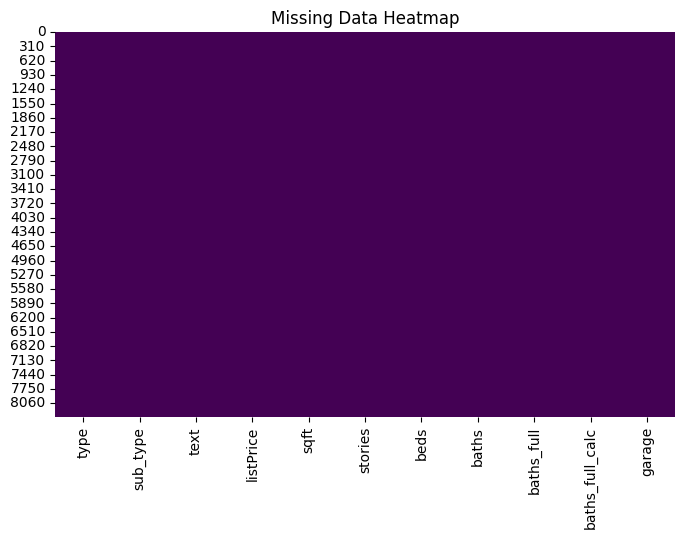

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

In [ ]:
print("\nCleaned Data (first 5 rows):")
data.head()


Cleaned Data (first 5 rows):


,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
0,single_family,condo,Beautifully maintained and spacious brick ranc...,479000,2492.0,1.0,4.0,3.0,1.0,2.0,2.0
1,single_family,condo,"$150, 000 PRICE CUT! And it still comes with a...",425000,3140.0,3.0,4.0,5.0,4.0,4.0,1.0
2,single_family,condo,Located on a quiet cul-de-sac in the desirable...,390000,2132.0,1.0,4.0,2.0,2.0,2.0,2.0
3,condos,condo,"3 bedroom, 3 bathroom Aspen Hills condo. LIST ...",100000,1328.0,2.0,3.0,3.0,2.0,2.0,1.0
4,townhomes,townhouse,Welcome to this beautiful townhome in Ridgevie...,375000,1615.0,2.0,3.0,3.0,1.0,2.0,2.0
